In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#00838F""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1


In [3]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]


min_range = -500
max_range = +500

anno = (
    anno
    .with_columns(
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose protein domain
        # (pl.col('mobi_curated_disorder_priority') == True) &
        # (pl.col('ted_domain') == True) &
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('low_complexity_domain') == True) &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &

        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

tss,strand,abexp_abs_max,promoterai,promoterai_abs,gene_name,verphylop,dist_to_tss,pangolin_score,cadd_raw,absplice_dna_max,delta_score,gpn_score,gpn_star_llr_calibrated_mean,absplice2_max,region,gene_length,score_pai3d,am_pathogenicity,id,esmscoremissense
i64,str,f32,f32,f32,str,f32,i64,f32,f32,f32,f32,f32,f32,f32,str,i64,f32,f32,str,f32
212414901,"""-1""",2.910019,0.0,0.0,"""PACC1""",0.079,940,0.0,0.424028,0.003,0.0,-1.38,-0.228884,0.000321,"""ENSG00000065600""",50975,0.0,0.0,"""chr1:212413961:C:T""",0.0
26171128,"""-1""",0.019552,0.0,0.0,"""APP""",-0.906,146225,0.04,-0.383115,0.001,0.0,-1.44,-0.091653,0.000034,"""ENSG00000142192""",290580,0.0,0.0,"""chr21:26024903:C:A""",0.0
9206764,"""1""",0.005501,0.0,0.0,"""ASAP2""",-0.084,101113,0.0,0.069795,0.001,0.0,-1.47,-0.539465,0.000033,"""ENSG00000151693""",198920,0.0,0.0,"""chr2:9307877:C:T""",0.0
202808487,"""-1""",0.006438,0.0,0.0,"""KDM5B""",0.665,76792,0.0,0.356601,0.001,0.0,-1.66,-0.249852,0.000033,"""ENSG00000117139""",83994,0.0,0.0,"""chr1:202731695:A:T""",0.0
212414901,"""-1""",0.005501,0.0,0.0,"""PACC1""",-1.454,7261,0.0,-0.322957,0.001,0.0,-0.58,0.929578,0.000033,"""ENSG00000065600""",50975,0.0,0.0,"""chr1:212407640:G:C""",0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
247416155,"""1""",0.0,0.0,0.0,"""NLRP3""",0.129,-71527,0.0,-0.197536,0.0,0.0,-0.33,1.181323,0.0,"""ENSG00000162711""",32954,0.0,0.0,"""chr1:247344628:T:C""",0.0
127854658,"""-1""",0.0,0.0,0.0,"""ENG""",0.129,47156,0.0,0.16376,0.0,0.0,-1.25,0.43518,0.0,"""ENSG00000106991""",39647,0.0,0.0,"""chr9:127807502:A:T""",0.0
247416155,"""1""",0.0,0.0,0.0,"""NLRP3""",0.129,-62333,0.0,0.447299,0.0,0.0,-0.12,1.050574,0.0,"""ENSG00000162711""",32954,0.0,0.0,"""chr1:247353822:T:C""",0.0


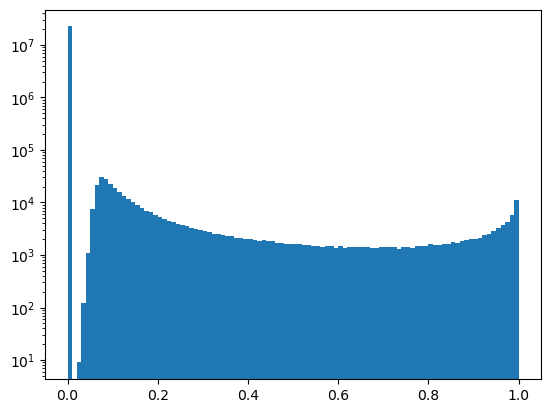

In [4]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100, log=True)
plt.show()

In [5]:
selected_annos = anno_config_df.filter(
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
    (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'pangolin_score', 'abexp_abs_max']))
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_generank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        anno_score_genecount = pl.len().over(["region", "annotation"]).cast(pl.Int32),
        
        # annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["annotation"]).cast(pl.Float32),
        
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="average", descending=True).over(["annotation"]).cast(pl.Float32),

        anno_score_count = pl.len().over(["annotation"]).cast(pl.Int32)
    )
    # .with_columns(
    #     annotation_score_dircor_geneptile = pl.col('annotation_score_dircor_generank') / pl.col('anno_score_genecount').round(4).cast(pl.Float32),
    #     annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    # )
    .drop(['anno_score_genecount', 'anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_generank,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32,f32
"""chr1:212413961:C:T""","""ENSG00000065600""","""am_pathogenicity""",0.0,"""missense""",1,10295.5,1.1616916e7
"""chr21:26024903:C:A""","""ENSG00000142192""","""am_pathogenicity""",0.0,"""missense""",1,54147.0,1.1616916e7
"""chr2:9307877:C:T""","""ENSG00000151693""","""am_pathogenicity""",0.0,"""missense""",1,36446.5,1.1616916e7
"""chr1:202731695:A:T""","""ENSG00000117139""","""am_pathogenicity""",0.0,"""missense""",1,16208.5,1.1616916e7
"""chr1:212407640:G:C""","""ENSG00000065600""","""am_pathogenicity""",0.0,"""missense""",1,10295.5,1.1616916e7
…,…,…,…,…,…,…,…
"""chr1:247344628:T:C""","""ENSG00000162711""","""abexp_abs_max""",0.0,"""regulatory_nondir""",1,16168.0,2.2138658e7
"""chr9:127807502:A:T""","""ENSG00000106991""","""abexp_abs_max""",0.0,"""regulatory_nondir""",1,1433.5,2.2138658e7
"""chr1:247353822:T:C""","""ENSG00000162711""","""abexp_abs_max""",0.0,"""regulatory_nondir""",1,16168.0,2.2138658e7


In [6]:
# ptile_counts_df = (
#     melted_anno
#     .group_by(['annotation', 'annotation_score_dircor_geneptile'])
#     .agg(
#         # n_vars_at_geneptile = pl.len()
#         n_vars_at_ptile = pl.len()
#     )
#     .sort('annotation_score_dircor_geneptile', descending=True)
#     .with_columns(
#         # n_vars_above_geneptile = pl.col('n_vars_at_geneptile').cum_sum().over('annotation')
#         n_vars_above_ptile = pl.col('n_vars_at_ptile').cum_sum().over('annotation')
#     )
# )

# melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_geneptile'], how='inner')
# melted_anno

In [7]:
# ct_df = melted_anno.group_by('annotation').agg(
#     n_vars = pl.len(),
#     max_ptile = pl.col('annotation_score_dircor_geneptile').max(),
# ).sort('n_vars', descending=True)

# # ct_df['max_ptile'].min()

# # assert ct_df['max_ptile'].min() == 1.0
# ct_df

In [8]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

if pheno_list_type is not None:
    gene_trait_df = gene_trait_df.filter(pl.col('phenotype').is_in(pheno_list))

gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Odds ratio computation

In [10]:
n_steps = 101
min_rank_cutoff = 1000
max_rank_cutoff = 10_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
1000
1096
1202
1318
1445
…
6918309
7585775
8317637


In [11]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    # .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_rank_desc", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,i64,u64,u64,u64,u64,f64
"""pangolin_score""","""ENSG00000152270""","""PDE3B""","""apolipoprotein_b_int""",10000000,49,4624,498,43113,0.917397
"""gpn_star_llr_calibrated_mean""","""ENSG00000145850""","""TIMD4""","""cholesterol_int""",10000000,49,3843,68,6438,1.207168
"""am_pathogenicity""","""ENSG00000116478""","""HDAC1""","""forced_expiratory_volume_in_1s…",10000000,1,115,101,8113,0.698493
"""pangolin_score""","""ENSG00000128849""","""CGNL1""","""gamma_glutamyltransferase_int""",10000000,60,5357,387,34518,0.998997
"""cadd_raw""","""ENSG00000106991""","""ENG""","""high_light_scatter_reticulocyt…",10000000,50,4647,79,6113,0.832577
…,…,…,…,…,…,…,…,…,…
"""am_pathogenicity""","""ENSG00000163554""","""SPTA1""","""mean_sphered_cell_volume_int""",1000,0,0,212,17934,NaN
"""pangolin_score""","""ENSG00000156515""","""HK1""","""glycated_haemoglobin_hba1c_int""",1000,1,0,305,26858,inf
"""pangolin_score""","""ENSG00000105610""","""KLF1""","""mean_corpuscular_volume_int""",1000,0,0,28,2532,NaN


## Plotting

In [12]:
# or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_{or_threshold_pheno}_ranks_{min_rank_cutoff}_wgs_EUR_genebass1e6_maf1e3.parquet')
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

In [13]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""abexp_abs_max""",3.0,1000,-3.0,238,0.0,6.329519,1.253881,8.787126,3.871912,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
"""am_pathogenicity""",3.0,1000,-3.0,429,0.0,10.01388,1.351011,12.661861,7.365899,"""#FFCA28""","""AlphaMissense""","""missense"""
"""cadd_raw""",3.0,1000,-3.0,475,0.0,8.338047,1.8814,12.025592,4.650502,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_star_llr_calibrated_mean""",3.0,1000,-3.0,403,0.0,6.962378,1.314546,9.538889,4.385867,"""#942c80""","""GPN-Star""","""conservation"""
"""pangolin_score""",3.0,1000,-3.0,385,0.0,3.654798,0.835602,5.292578,2.017018,"""#2E7D32""","""Pangolin""","""splicing"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""pangolin_score""",7.0,10000000,-7.0,1162,1.101695,1.24887,0.024511,1.296911,1.200829,"""#2E7D32""","""Pangolin""","""splicing"""
"""cadd_raw""",7.0,10000000,-7.0,1176,1.087278,1.167556,0.009919,1.186998,1.148114,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""abexp_abs_max""",7.0,10000000,-7.0,1148,1.067907,1.161633,0.015172,1.191371,1.131896,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


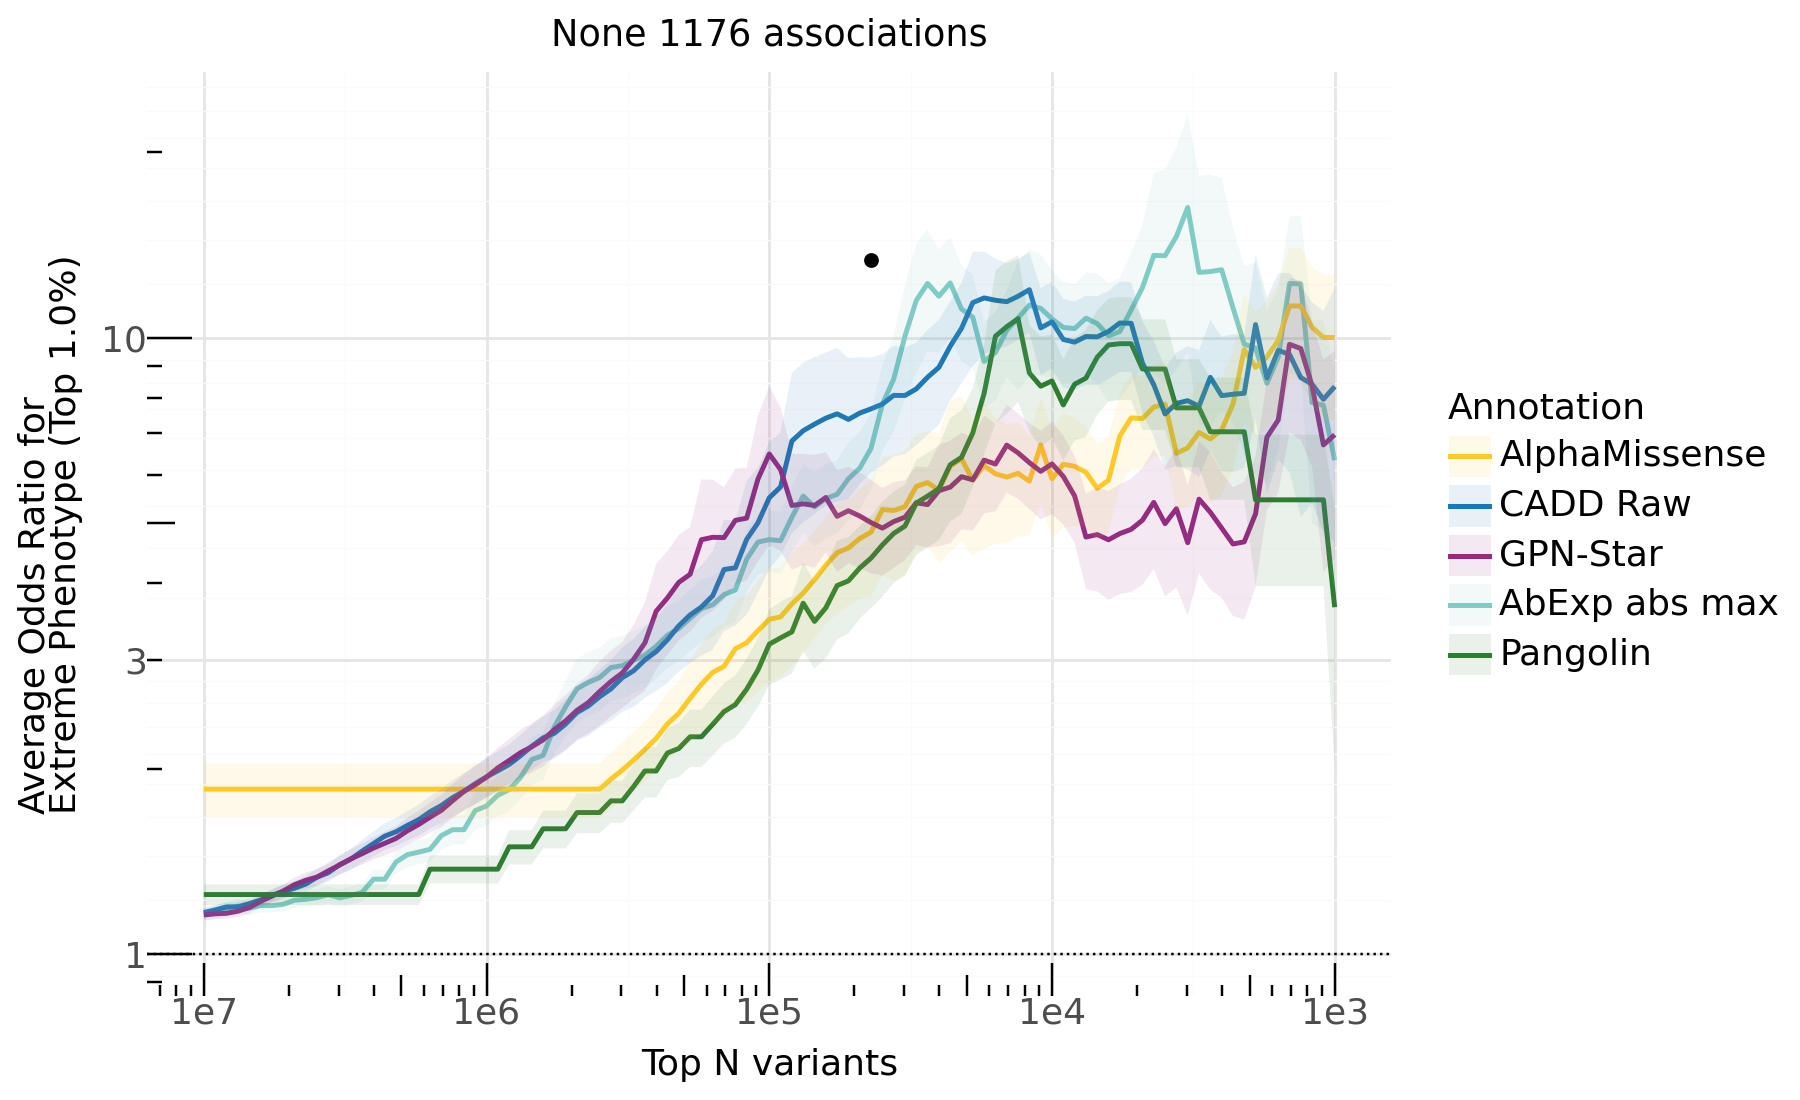

In [18]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('annotation').is_in(['am_pathogenicity', 'score_pai3d', 'esmscoremissense']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw']))
        (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'pangolin_score']))
        # (pl.col('annotation').is_in(['gpn_score', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'pangolin_score', 'abexp_abs_max', 'promoterai_abs']))
        # (pl.col('category').is_in(['missense', 'genetic_diversity']))
        # (pl.col('log_rank_cutoff_inv') <= -3)
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

# Determine legend order based on final average odds ratio
legend_order = (
    plot_df.sort("log_rank_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

loftee_or = pl.DataFrame({
    'region': ['gene_body_5kb', 'gene_body', 'cds'],
    'n_vars': [-np.log10(43_640), -np.log10(43_640), -np.log10(43_640)],
    'mean_or': [13.392815, 11.88451, 7.703493],
})

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + geom_point(loftee_or.filter(pl.col('region')=='gene_body_5kb'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"{pheno_list_type} {gene_trait_df.shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [15]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""abexp_abs_max""",3.0,1000,-3.0,238,0.0,6.329519,1.253881,8.787126,3.871912,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
"""am_pathogenicity""",3.0,1000,-3.0,429,0.0,10.01388,1.351011,12.661861,7.365899,"""#FFCA28""","""AlphaMissense""","""missense"""
"""cadd_raw""",3.0,1000,-3.0,475,0.0,8.338047,1.8814,12.025592,4.650502,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_star_llr_calibrated_mean""",3.0,1000,-3.0,403,0.0,6.962378,1.314546,9.538889,4.385867,"""#942c80""","""GPN-Star""","""conservation"""
"""pangolin_score""",3.0,1000,-3.0,385,0.0,3.654798,0.835602,5.292578,2.017018,"""#2E7D32""","""Pangolin""","""splicing"""
